In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))
from evaluation.plot_attention_patterns import load_stats, load_example, plot_heatmap, plot_sink_strength, plot_entropy, plot_gate

## Attention pattern analysis
All 4 pretrained models: **full**, **gated**, **off-by-one**, **sink**.
- Prefix / suffix: 50 / 50 tokens
- Repetition buckets: 0, 1, 2, 4, 8, 16, 32, 64, 128, 256
- 660 samples per bucket (4 GPUs × 165 samples)

Models with missing data are skipped automatically.

In [4]:
EXP_BASE = '../results/mem-results/SparseGutenberg'

MODELS = {
    'full':  'llama3-1b-full-attn-fineweb40B-gutenberg3B',
    'gated': 'llama3-1b-gated-attn-fineweb40B-gutenberg3B',
    'obo':   'llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B-te215',
    'sink':  'llama3-1b-sink-attn-fineweb40B-gutenberg3B-te215',
}

REPS = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
OFFSET, PREFIX_LEN, SUFFIX_LEN = 0, 50, 50

In [5]:
from evaluation.plot_attention_patterns import load_stats, load_example

def _try_load_stats(exp_base, name, rep, offset, prefix_len, suffix_len):
    try:
        return load_stats(exp_base, name, rep, offset, prefix_len, suffix_len)
    except FileNotFoundError:
        return None

def _try_load_example(exp_base, name, rep, offset, prefix_len, suffix_len):
    try:
        return load_example(exp_base, name, rep, offset, prefix_len, suffix_len)
    except FileNotFoundError:
        return None

stats = {
    key: {rep: _try_load_stats(EXP_BASE, name, rep, OFFSET, PREFIX_LEN, SUFFIX_LEN)
          for rep in REPS}
    for key, name in MODELS.items()
}
examples = {
    key: {rep: _try_load_example(EXP_BASE, name, rep, OFFSET, PREFIX_LEN, SUFFIX_LEN)
          for rep in REPS}
    for key, name in MODELS.items()
}

In [53]:
print('Data availability (rep counts per model):')
for key in MODELS:
    available = [r for r in REPS if stats[key][r] is not None]
    print(f'  {key:6s}: {len(available)}/10 reps  {available}')

Data availability (rep counts per model):
  full  : 10/10 reps  [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
  gated : 10/10 reps  [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
  obo   : 10/10 reps  [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
  sink  : 10/10 reps  [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]


### Attention heatmap
Decode-step × key-position attention weights (log scale).  
Dashed line = prefix / suffix boundary.  
Top: rep=0 (unseen), bottom: rep=256 (heavily repeated).

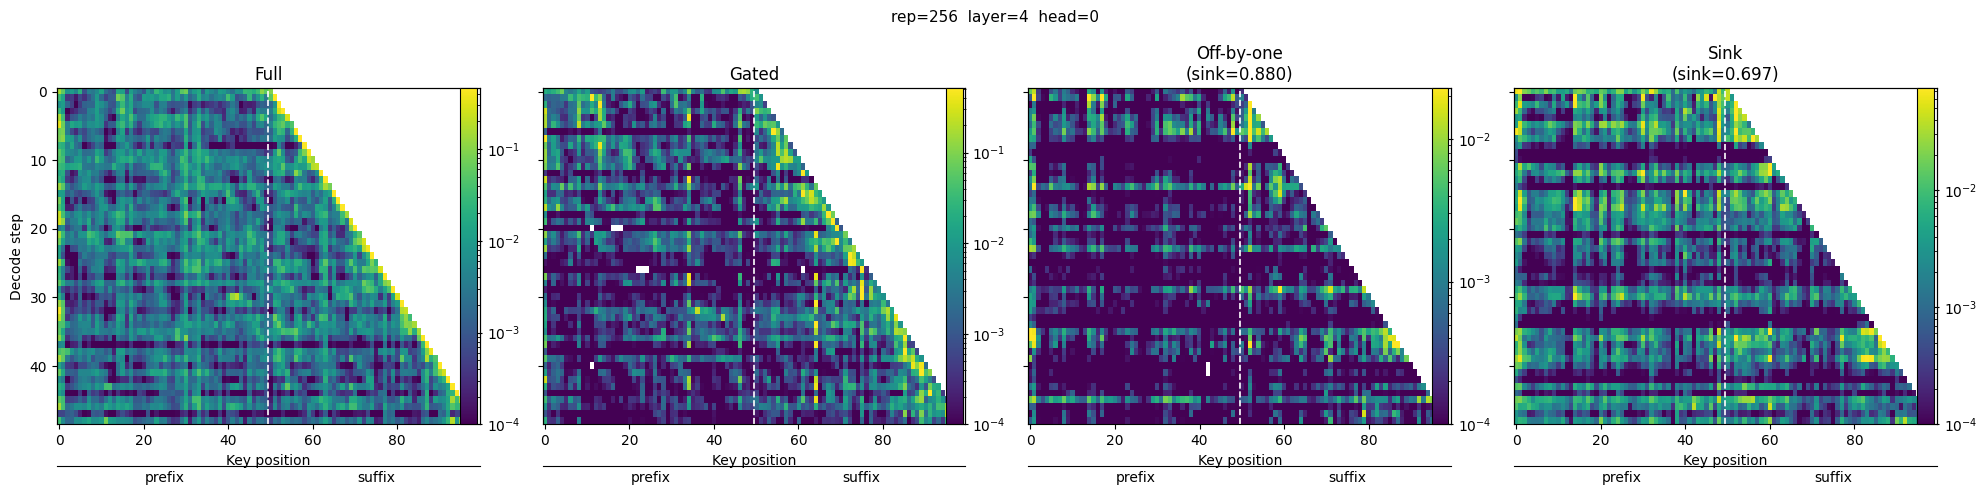

In [79]:
from evaluation.plot_attention_patterns import plot_heatmap

available = {k: v for k, v in examples.items() if v[0] is not None}
plot_heatmap(available, rep=256, layer=4, head=0)
plt.show()

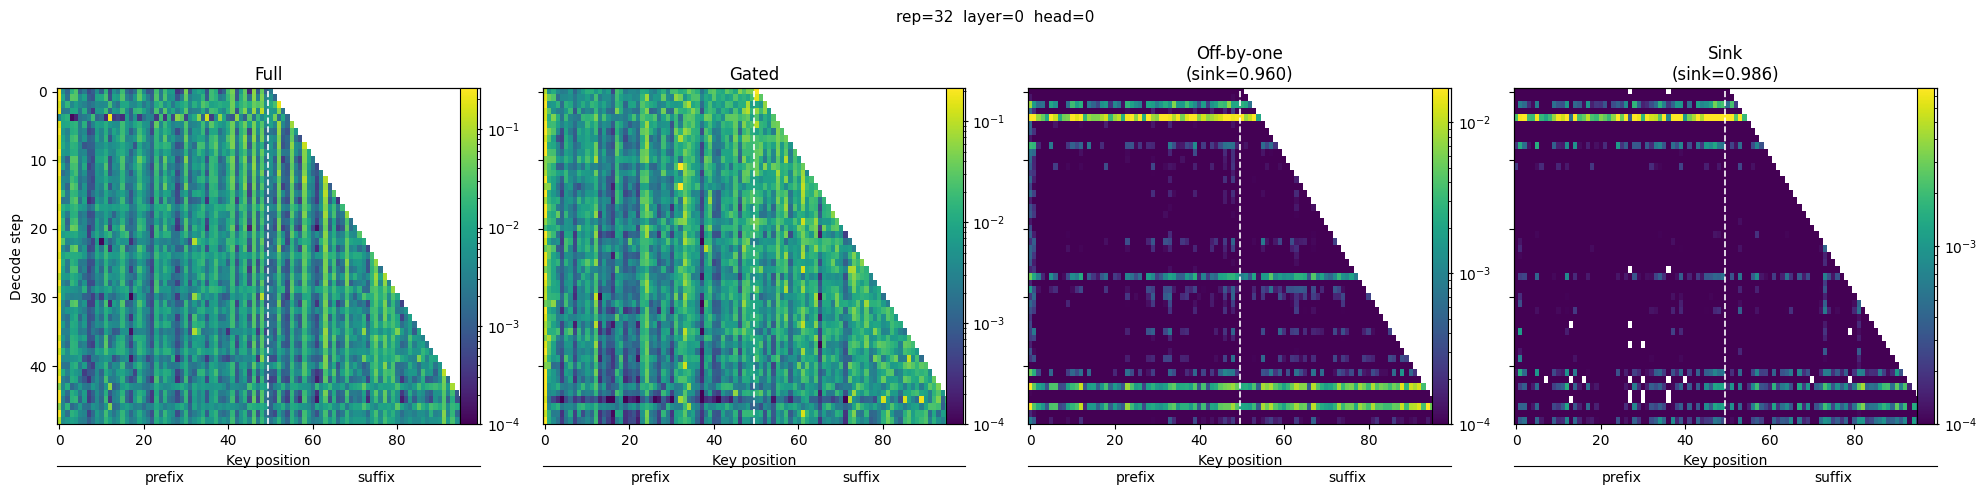

In [98]:
available = {k: v for k, v in examples.items() if v.get(256) is not None}
plot_heatmap(available, rep=32, layer=0, head=0)
plt.show()

#### Explore different layers / heads
Change `layer` and `head` to see how attention patterns vary across the network.

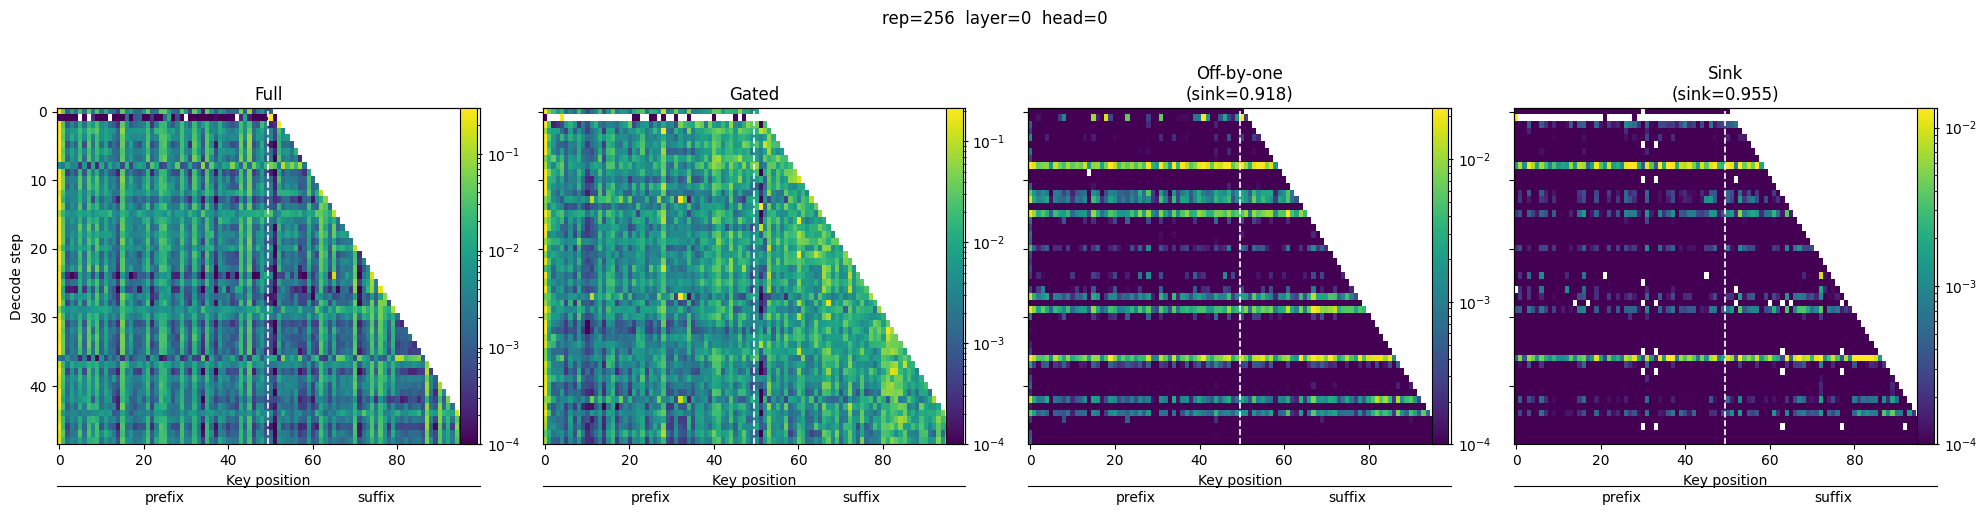

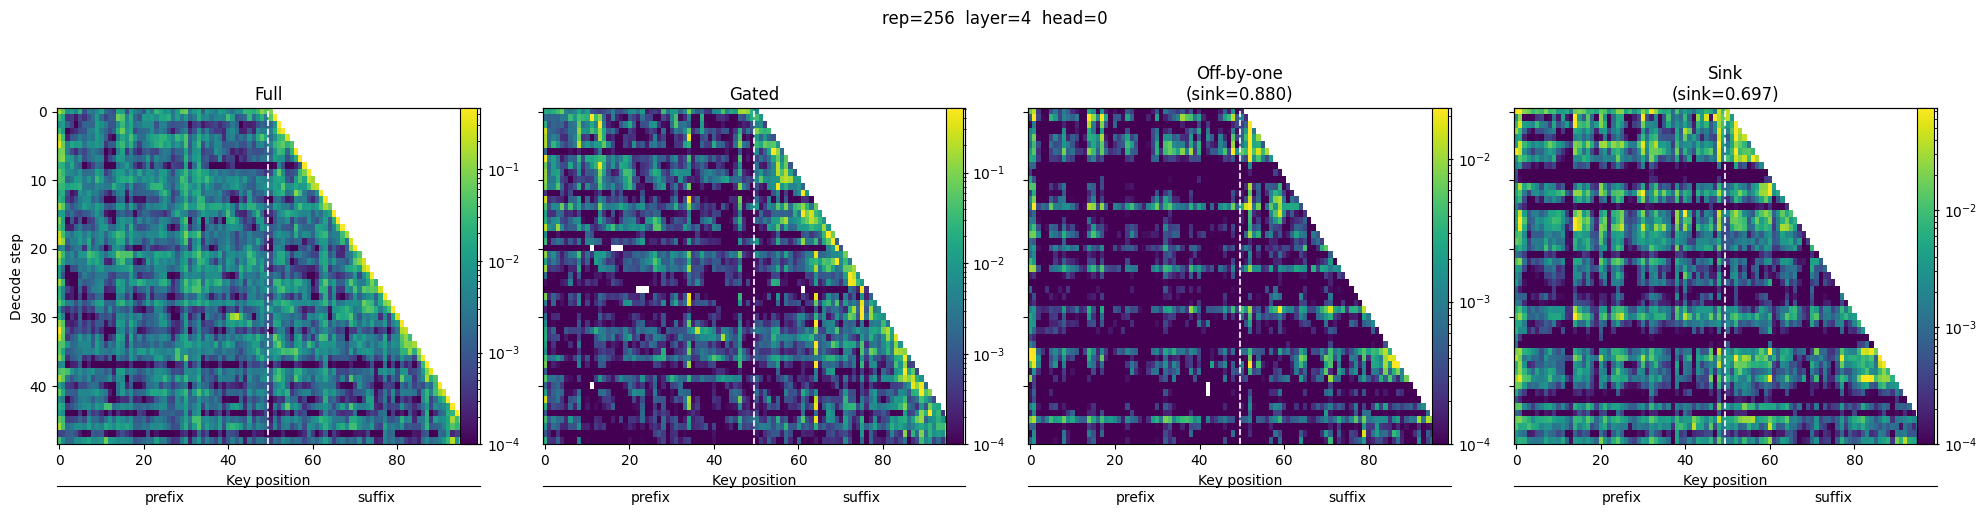

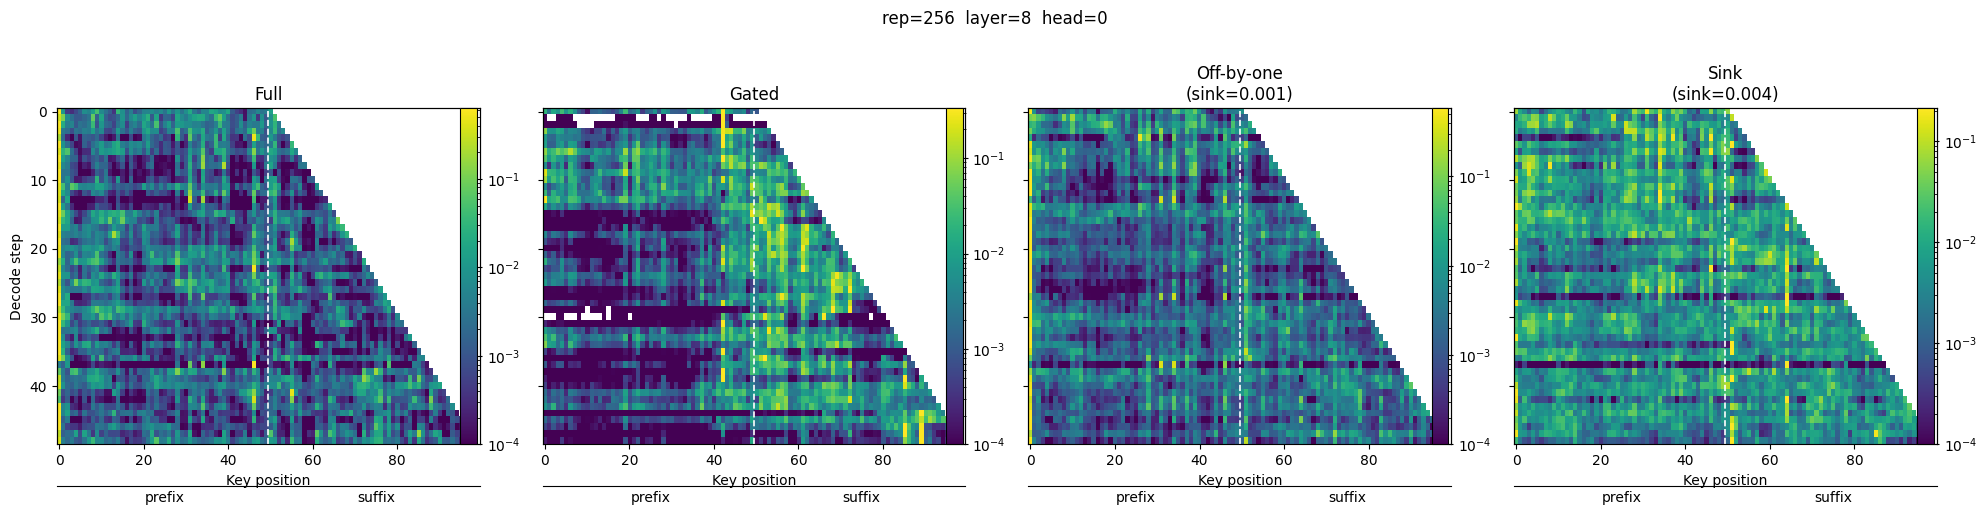

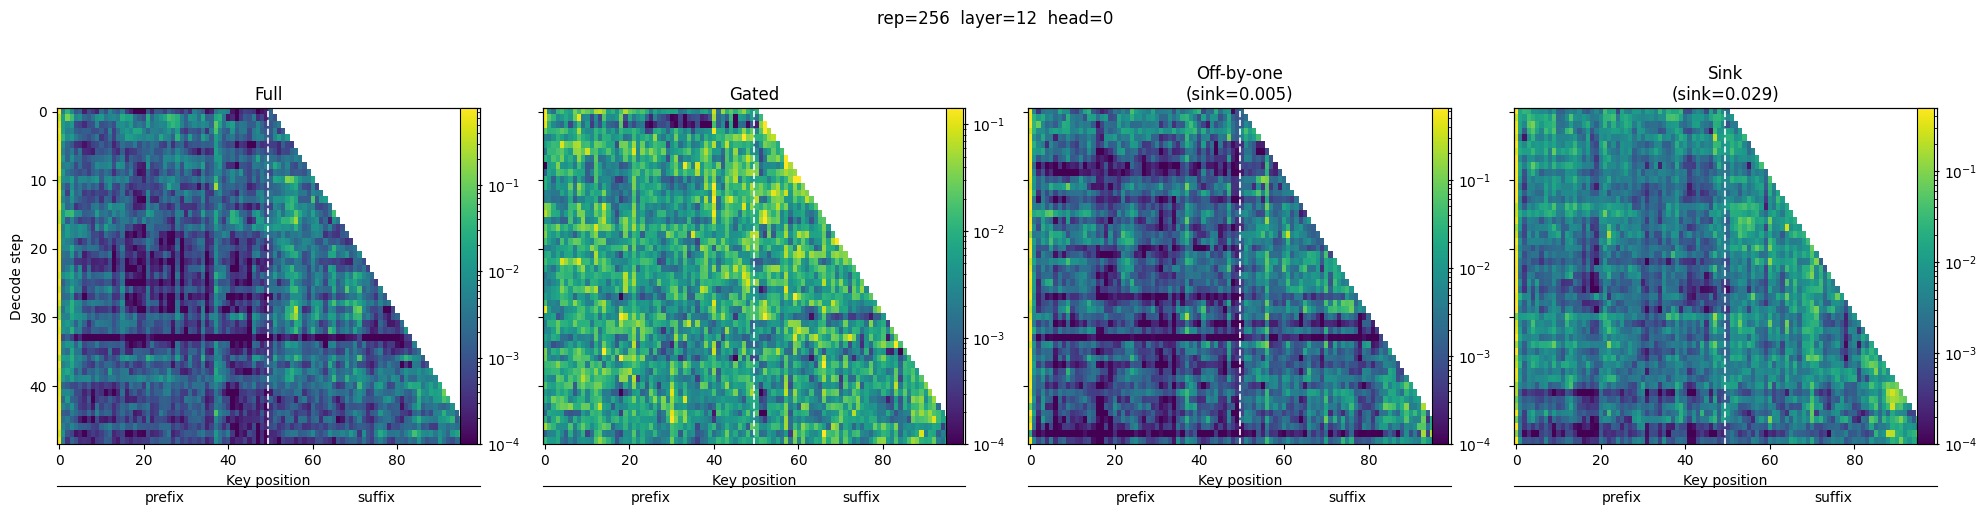

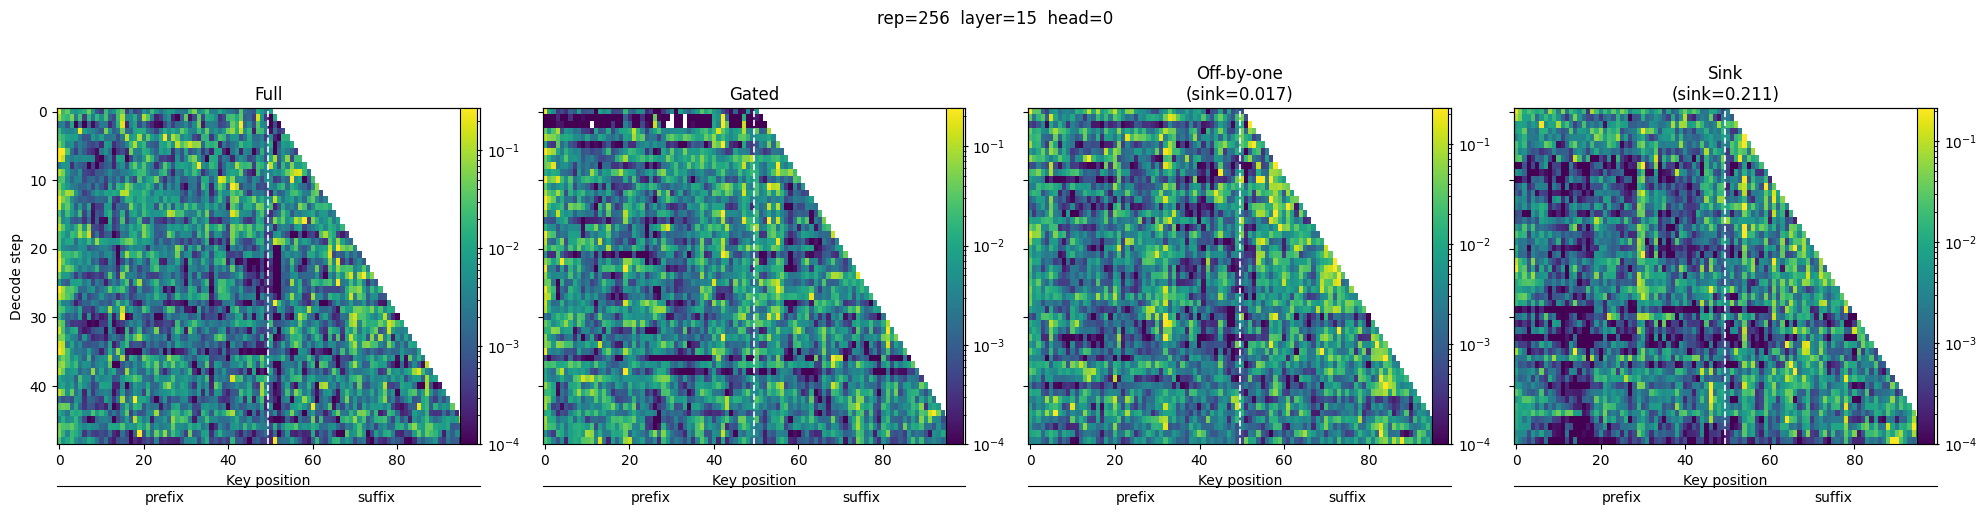

In [43]:
available = {k: v for k, v in examples.items() if v.get(256) is not None}
for layer in [0, 4, 8, 12, 15]:
    plot_heatmap(available, rep=256, layer=layer, head=0)
    plt.suptitle(f'rep=256  layer={layer}  head=0', y=1.02)
    plt.show()

### Gate scalar (gated model)
Per-head gate values across decode steps, and effective attention (gate × attn) for head 0.

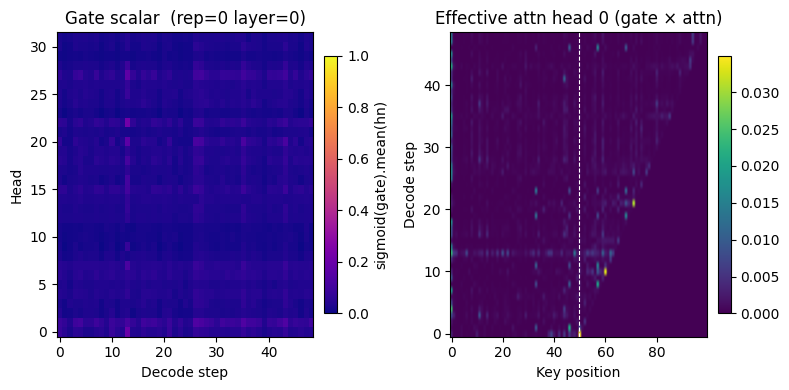

In [44]:
from evaluation.plot_attention_patterns import plot_gate

if examples['gated'][0] is not None:
    plot_gate(examples['gated'][0], rep=0, layer=0)
    plt.show()

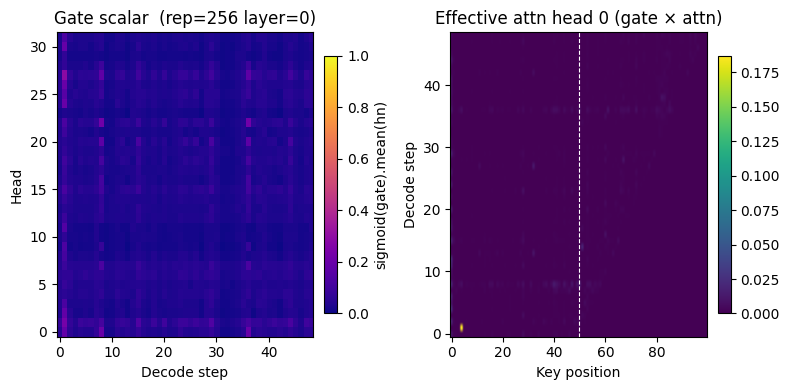

In [45]:
if examples['gated'].get(256) is not None:
    plot_gate(examples['gated'][256], rep=256, layer=0)
    plt.show()

### BOS / sink strength and entropy vs. repetition

KeyError: 8

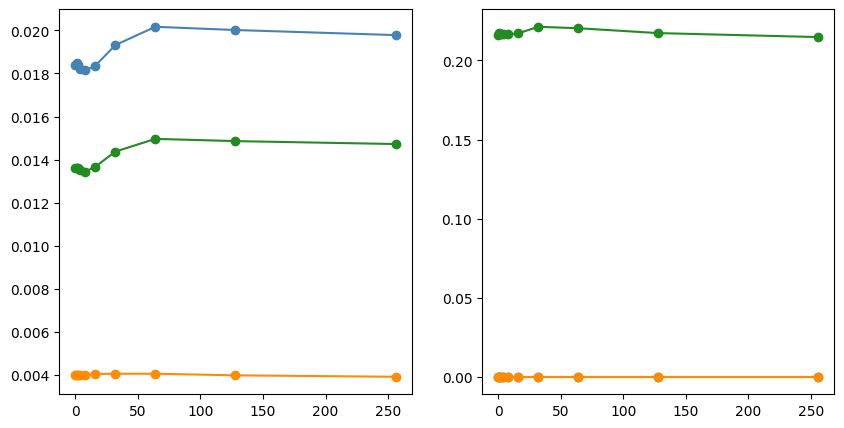

In [46]:
from evaluation.plot_attention_patterns import plot_sink_strength

# keep only models with at least one loaded rep
available_stats = {k: {r: v for r, v in reps.items() if v is not None}
                   for k, reps in stats.items()}
available_stats = {k: v for k, v in available_stats.items() if v}
available_models = {k: MODELS[k] for k in available_stats}

plot_sink_strength(available_stats, available_models)
plt.show()

KeyError: 8

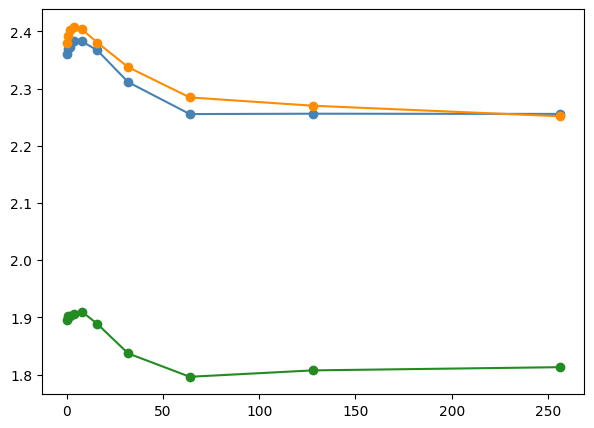

In [47]:
from evaluation.plot_attention_patterns import plot_entropy

plot_entropy(available_stats, available_models)
plt.show()

#### Entropy per layer
Does entropy vary more across layers than across repetitions?

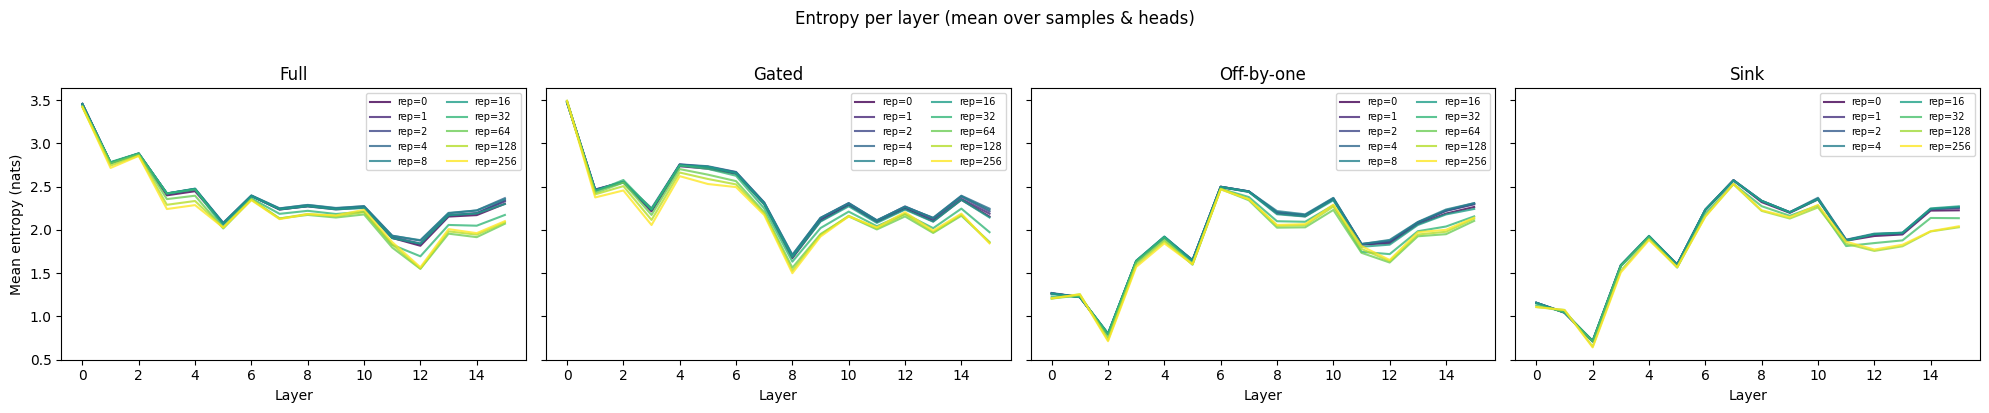

In [48]:
fig, axes = plt.subplots(1, len(available_stats), figsize=(5*len(available_stats), 4), sharey=True)
if len(available_stats) == 1:
    axes = [axes]

from evaluation.plot_attention_patterns import _model_label, _model_color

for ax, (key, rep_dict) in zip(axes, available_stats.items()):
    reps_avail = sorted(rep_dict.keys())
    n_layers = rep_dict[reps_avail[0]]['entropy'].shape[1]
    cmap = plt.cm.viridis
    for i, rep in enumerate(reps_avail):
        ent_per_layer = rep_dict[rep]['entropy'].mean(axis=(0, 2, 3))  # [L]
        ax.plot(range(n_layers), ent_per_layer,
                color=cmap(i / max(len(reps_avail)-1, 1)),
                label=f'rep={rep}', alpha=0.8)
    ax.set_title(_model_label(key))
    ax.set_xlabel('Layer')
    if ax is axes[0]:
        ax.set_ylabel('Mean entropy (nats)')
    ax.legend(fontsize=7, ncol=2)

plt.suptitle('Entropy per layer (mean over samples & heads)', y=1.02)
plt.tight_layout()
plt.show()

In [1]:
from evaluation.plot_attention_patterns import plot_full_grid

available = {k: v for k, v in examples.items() if v.get(256) is not None}
fig = plot_full_grid(
    available,
    rep=256,
    cell_w=1.5,
    cell_h=0.8,
    save_path='../results/plots/full_grid_rep256.pdf',
)
plt.show()
print('saved to results/plots/full_grid_rep256.pdf')

NameError: name 'examples' is not defined